In [1]:
import os, sys
from dotenv import load_dotenv

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
PIPELINE_DIR = os.path.join(ROOT, "pipeline")
os.makedirs(PIPELINE_DIR, exist_ok=True)
os.makedirs(os.path.join(ROOT, "outputs/evaluation"), exist_ok=True)

if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

load_dotenv(os.path.join(ROOT, "secrets.env"))
HF_TOKEN   = os.getenv("HF_TOKEN")
GROQ_TOKEN = os.getenv("GROQ_API_KEY")

assert HF_TOKEN   and HF_TOKEN.startswith("hf_"),   "⚠ HF_TOKEN missing"
assert GROQ_TOKEN and GROQ_TOKEN.startswith("gsk_"), "⚠ GROQ_API_KEY missing"
print("✓ Secrets loaded")
print(f"✓ Pipeline dir: {PIPELINE_DIR}")


✓ Secrets loaded
✓ Pipeline dir: c:\Users\nethr\UCD Spring\ML\Project\ML_SYS_DEP\pipeline


In [2]:
import torch
from groq import Groq
from pipeline.stage2a_transformer import load_transformer
from pipeline.stage2b_retriever   import load_rag_artifacts
from pipeline.router               import route_ticket, RoutingResult

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Groq client
groq_client = Groq(api_key=GROQ_TOKEN)
print("✓ Groq client ready")

# Transformer
print("Loading transformer...")
model, tokenizer, queue_encoder, priority_encoder = load_transformer(
    "Nethra19/multitask-ticket-model", HF_TOKEN, device
)
print(f"✓ Transformer loaded — {len(queue_encoder.classes_)} queue classes")

# RAG artifacts
print("Loading RAG artifacts...")
faiss_index, bm25, all_chunks, cross_encoder, priority_index, priority_chunks = load_rag_artifacts(
    "Rarry/Improved_RAG", HF_TOKEN
)
print(f"✓ RAG loaded — {len(all_chunks)} dept chunks, {len(priority_chunks)} priority chunks")

Device: cuda
✓ Groq client ready
Loading transformer...
19:13:18  INFO      [stage2a.transformer]  Loading transformer from Nethra19/multitask-ticket-model


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

19:13:19  INFO      [stage2a.transformer]  Transformer ready — 8 queue classes: ['Billing and Payments', 'Customer Service', 'General Inquiry', 'Human Resources', 'Returns and Exchanges', 'Sales and Pre-Sales', 'Service Outages and Maintenance', 'Technical & IT Support']
19:13:19  INFO      [stage2a.transformer]  Priority classes : ['high', 'low', 'medium']
✓ Transformer loaded — 8 queue classes
Loading RAG artifacts...
19:13:19  INFO      [stage2b.retriever]  Loading RAG artifacts from Rarry/Improved_RAG


rag_priority_index.faiss:   0%|          | 0.00/9.26k [00:00<?, ?B/s]

rag_priority_metadata.pkl:   0%|          | 0.00/9.96k [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


19:13:25  INFO      [stage2b.retriever]  Dept index: 24 vectors | Priority index: 3 vectors
19:13:25  INFO      [stage2b.retriever]  Dept chunks: 24 | Priority chunks: 3
✓ RAG loaded — 24 dept chunks, 3 priority chunks


In [3]:
TEST_TICKET = """
Dear Support Team,

I hope you are well. I have been charged twice for my subscription 
this month. My card was billed on the 1st and again on the 3rd for 
the same amount. Please investigate and process a refund for the 
duplicate charge as soon as possible.

Thanks,
Rajat
"""

result = route_ticket(
    TEST_TICKET, groq_client,
    model, tokenizer, queue_encoder, priority_encoder, device,
    faiss_index, bm25, all_chunks, cross_encoder,
    priority_index, priority_chunks
)

print("=" * 65)
print("PIPELINE RESULT")
print("=" * 65)
print(f"Cleaned text     : {result.cleaned_text}")
print(f"\nTransformer      : {result.transformer_dept} ({result.transformer_conf*100:.1f}%)")
print(f"Top-3            : {result.transformer_top3}")
print(f"\nRAG top chunk    : {result.rag_chunks[0]['chunk']['dept']} "
      f"(score={result.rag_chunks[0]['ce_score']:.3f})")
print(f"\n── FINAL DECISION ──")
print(f"Department  : {result.department}")
print(f"Priority    : {result.priority}")
print(f"Confidence  : {result.confidence}")
print(f"Reasoning   : {result.reasoning}")


19:13:25  INFO      [router]  ============================================================
19:13:25  INFO      [router]  NEW TICKET (276 chars): '\nDear Support Team,\n\nI hope you are well. I have been charged twice for my subsc'
19:13:25  INFO      [router]  ============================================================
19:13:25  INFO      [stage1.rewriter]  Stage 1 — rewriting ticket (276 chars)
19:13:25  DEBUG     [stage1.rewriter]  Raw input: '\nDear Support Team,\n\nI hope you are well. I have been charged twice for my subscription \nthis month. My card was billed '
19:13:26  INFO      [stage1.rewriter]  Stage 1 done — subject: 'Duplicate Subscription Charge Issue'
19:13:26  DEBUG     [stage1.rewriter]  Urgency signals : ['as soon as possible']
19:13:26  DEBUG     [stage1.rewriter]  Tech keywords   : ['subscription', 'refund', 'card', 'billed']
19:13:26  DEBUG     [stage1.rewriter]  Explanation     : The customer is likely contacting the billing department due to a payment issue.
1

In [4]:
import pandas as pd
from tqdm import tqdm
import time

test_df = pd.read_csv(os.path.join(ROOT, "data/processed/test.csv"))

N_PER_CLASS = 10

# Build stratified sample with concat — no apply() pandas issues
sample_df = pd.concat([
    group.sample(min(len(group), N_PER_CLASS), random_state=42)
    for _, group in test_df.groupby("queue")
]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"✓ Stratified sample: {len(sample_df)} rows")
print(sample_df["queue"].value_counts().sort_index())

✓ Stratified sample: 80 rows
queue
Billing and Payments               10
Customer Service                   10
General Inquiry                    10
Human Resources                    10
Returns and Exchanges              10
Sales and Pre-Sales                10
Service Outages and Maintenance    10
Technical & IT Support             10
Name: count, dtype: int64


In [5]:
RESULTS_PATH = os.path.join(ROOT, "outputs/evaluation/pipeline_results.csv")

# Resume from where we left off if a partial results file exists
if os.path.exists(RESULTS_PATH):
    done_df    = pd.read_csv(RESULTS_PATH)
    results_log = done_df.to_dict("records")
    already_done = len(results_log)
    print(f"✓ Resuming from row {already_done} — {len(sample_df) - already_done} remaining")
else:
    results_log  = []
    already_done = 0

remaining_df = sample_df.iloc[already_done:].reset_index(drop=True)

for _, row in tqdm(remaining_df.iterrows(), total=len(remaining_df)):
    raw_text = str(row["subject"]) + " " + str(row["body"])
    try:
        res = route_ticket(
            raw_text, groq_client,
            model, tokenizer, queue_encoder, priority_encoder, device,
            faiss_index, bm25, all_chunks, cross_encoder,
            priority_index, priority_chunks
        )
        results_log.append({
            "true_dept":        row["queue"],
            "true_priority":    row["priority"],
            "pred_dept":        res.department,
            "pred_priority":    res.priority,
            "confidence":       res.confidence,
            "transformer_dept": res.transformer_dept,
            "transformer_conf": res.transformer_conf,
        })
    except Exception as e:
        # Rate limit hit — save progress and stop cleanly
        if "rate_limit_exceeded" in str(e) or "429" in str(e):
            pd.DataFrame(results_log).to_csv(RESULTS_PATH, index=False)
            done = already_done + len(results_log) - already_done
            print(f"\n⚠ Groq rate limit hit at row {already_done + _ + 1}")
            print(f"  Progress saved ({len(results_log)} rows) — re-run tomorrow to resume")
            break
        # Any other error — log as ERROR and continue
        print(f"\n✗ Row {_}: {e}")
        results_log.append({
            "true_dept":        row["queue"],
            "true_priority":    row["priority"],
            "pred_dept":        "ERROR",
            "pred_priority":    "ERROR",
            "confidence":       "low",
            "transformer_dept": "ERROR",
            "transformer_conf": 0.0,
        })
    time.sleep(0.5)  # slightly longer sleep to reduce token burn rate
else:
    # Loop completed without hitting rate limit
    results_df = pd.DataFrame(results_log)
    results_df.to_csv(RESULTS_PATH, index=False)
    print(f"✓ Evaluation complete — {len(results_df)} tickets saved to pipeline_results.csv")


✓ Resuming from row 320 — -240 remaining


0it [00:00, ?it/s]

✓ Evaluation complete — 320 tickets saved to pipeline_results.csv


In [6]:
results_df = pd.read_csv(os.path.join(ROOT, "outputs/evaluation/pipeline_results.csv"))
print(f"✓ Loaded {len(results_df)} rows")
print(results_df["pred_dept"].value_counts())


✓ Loaded 320 rows
pred_dept
ERROR                              245
Technical & IT Support              38
Sales and Pre-Sales                  7
Customer Service                     7
General Inquiry                      6
Service Outages and Maintenance      6
Human Resources                      5
Billing and Payments                 4
Returns and Exchanges                2
Name: count, dtype: int64


FULL PIPELINE EVALUATION RESULTS
Department  Accuracy  : 37.3%
Department  Macro F1  : 40.0%
Priority    Accuracy  : 38.7%
Priority    Macro F1  : 35.8%

DEPARTMENT CLASSIFICATION REPORT:
                                 precision    recall  f1-score   support

           Billing and Payments       1.00      0.50      0.67         8
               Customer Service       0.29      0.17      0.21        12
                General Inquiry       0.17      0.10      0.12        10
                Human Resources       1.00      0.71      0.83         7
          Returns and Exchanges       0.50      0.09      0.15        11
            Sales and Pre-Sales       0.43      0.27      0.33        11
Service Outages and Maintenance       0.50      0.50      0.50         6
         Technical & IT Support       0.24      0.90      0.38        10

                       accuracy                           0.37        75
                      macro avg       0.51      0.41      0.40        75
       

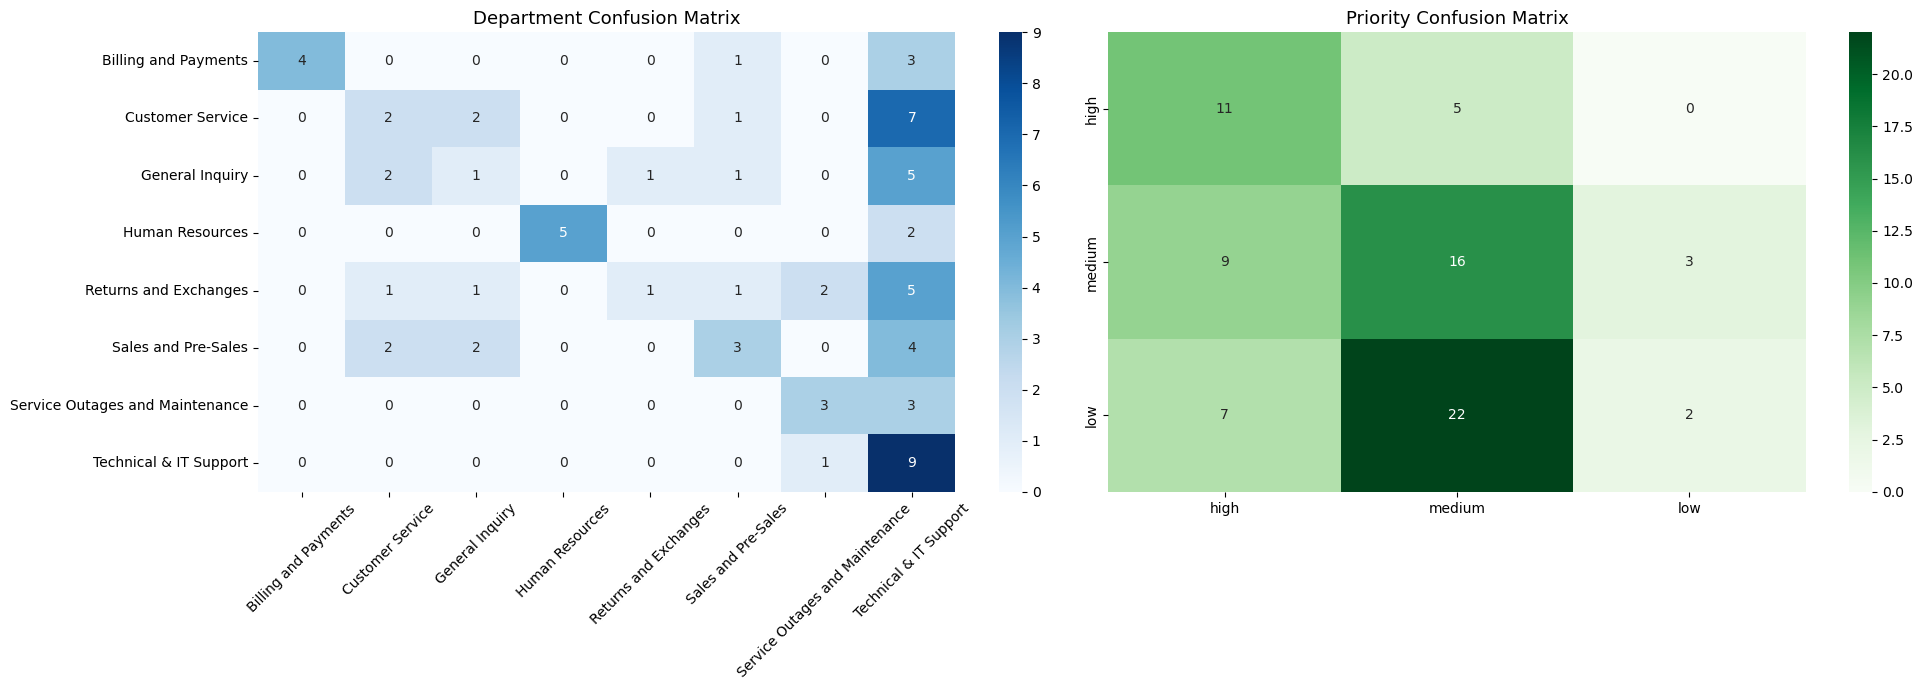

✓ Saved confusion_matrices.png
✓ Saved pipeline_results.csv


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, f1_score,
                              classification_report, confusion_matrix)

clean = results_df[results_df["pred_dept"] != "ERROR"].copy()

dept_acc  = accuracy_score(clean["true_dept"],     clean["pred_dept"])
dept_f1   = f1_score(clean["true_dept"],     clean["pred_dept"],     average="macro", zero_division=0)
prio_acc  = accuracy_score(clean["true_priority"], clean["pred_priority"])
prio_f1   = f1_score(clean["true_priority"], clean["pred_priority"], average="macro", zero_division=0)

print("=" * 55)
print("FULL PIPELINE EVALUATION RESULTS")
print("=" * 55)
print(f"Department  Accuracy  : {dept_acc*100:.1f}%")
print(f"Department  Macro F1  : {dept_f1*100:.1f}%")
print(f"Priority    Accuracy  : {prio_acc*100:.1f}%")
print(f"Priority    Macro F1  : {prio_f1*100:.1f}%")
print("=" * 55)
print("\nDEPARTMENT CLASSIFICATION REPORT:")
print(classification_report(clean["true_dept"], clean["pred_dept"], zero_division=0))

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
labels_q = sorted(clean["true_dept"].unique())
labels_p = ["high", "medium", "low"]

sns.heatmap(confusion_matrix(clean["true_dept"], clean["pred_dept"], labels=labels_q),
            annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_q, yticklabels=labels_q, ax=axes[0])
axes[0].set_title("Department Confusion Matrix", fontsize=13)
axes[0].tick_params(axis="x", rotation=45)

sns.heatmap(confusion_matrix(clean["true_priority"], clean["pred_priority"], labels=labels_p),
            annot=True, fmt="d", cmap="Greens",
            xticklabels=labels_p, yticklabels=labels_p, ax=axes[1])
axes[1].set_title("Priority Confusion Matrix", fontsize=13)

plt.tight_layout()
plt.savefig(os.path.join(ROOT, "outputs/evaluation/confusion_matrices.png"), dpi=150)
plt.show()
print("✓ Saved confusion_matrices.png")

# Save raw results
results_df.to_csv(os.path.join(ROOT, "outputs/evaluation/pipeline_results.csv"), index=False)
print("✓ Saved pipeline_results.csv")
